In [1]:
import sys 
import numpy as np
import matplotlib.pyplot as plt
import glob

import torch
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader

sys.path.append("../")

from oxels.datasets import PerspectiveImagesDataset
from oxels.networks import SwinUNet
from oxels.losses import original_loss_func
from oxels.augmentation import HueShift, MotionBlur, RandomKernel, RandomBrightnessContrast, PixelNoise, Sobel, Scharr, SequenceStrategy

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
#"harmless" augmentations
basic_augmentations = SequenceStrategy(
    [MotionBlur(), HueShift(), RandomBrightnessContrast()],
    probabilities=[0.8,0.8,0.8],
    ordered=False,
    at_most_one=False)

#more disruptive augmentations that should be applied sparsingly and collide with one another
advanced_agumentation = SequenceStrategy(
    [RandomKernel(), Sobel(), Scharr(), PixelNoise()],
    probabilities=None,
    ordered=False,
    at_most_one=True)

#all augmentations (order matters)
all_agumentations = SequenceStrategy(
    [basic_augmentations, advanced_agumentation],
    probabilities=[1.0, 0.2],
    ordered=True,
    at_most_one=False)

In [4]:
files = glob.glob("../../schenectadata/image-matching-challenge-2022/train/*/images/*.jpg")
dataset = PerspectiveImagesDataset(files, all_agumentations, 256+128, 256, 0.5)

In [5]:
batch_size = 4

In [6]:
loader = DataLoader(
    dataset,
    batch_size=batch_size,
    num_workers=1,
    pin_memory=True,
)

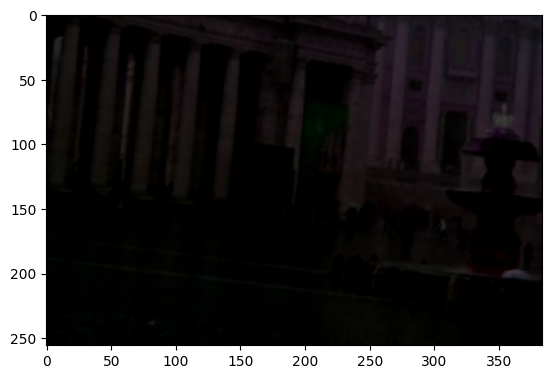

In [7]:
view1, view2, permutation, flags, mask1, mask2 = next(iter(loader))
plt.imshow(view1[0].detach().numpy().transpose((1,2,0)))

In [8]:
network = SwinUNet(height=256, width=256+128, channels=3, patch_size=4, num_stages=5, head_dim=64, patch_embed_dim=32, oxel_dim=32).to(device)

In [10]:
%%time
with torch.no_grad():
    oxels1 = network(view1.to(device))
    oxels2 = network(view2.to(device))
    print(original_loss_func(oxels1, oxels2, permutation.to(device), flags.to(device), mask1.to(device), mask2.to(device)))

tensor(0.8176, device='cuda:0')
CPU times: user 17.3 ms, sys: 0 ns, total: 17.3 ms
Wall time: 16.7 ms


In [ ]:
EPOCHS = 1000
LEARNING_RATE = 5e-5

optimizer = torch.optim.Adam(network.parameters(), lr=LEARNING_RATE)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)

for epoch in range(EPOCHS):
    network.train()
    total_loss = 0.0

    for view1, view2, permutation, flags, mask1, mask2 in loader:
        view1 = view1.to(device)
        view2 = view2.to(device)
        permutation = permutation.to(device)
        flags = flags.to(device)
        mask1 = mask1.to(device)
        mask2 = mask2.to(device)

        optimizer.zero_grad()
        oxels1 = network(view1)
        oxels2 = network(view2)

        loss = original_loss_func(oxels1, oxels2, permutation, flags, mask1, mask2)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    scheduler.step()  # update learning rate

    avg_loss = (total_loss * batch_size) / len(loader)
    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {avg_loss:.3f}, LR: {scheduler.get_last_lr()[0]:.2e}")

    # Save model checkpoint
    if epoch % 10 == 0:
        torch.save(network.state_dict(), f"../checkpoints/checkpoint_epoch_{epoch+1}.pth")

Epoch 1/1000, Loss: 0.674, LR: 5.00e-05
Epoch 2/1000, Loss: 0.519, LR: 5.00e-05


In [12]:
torch.save(network.state_dict(), f"../checkpoints/checkpoint_epoch_{epoch+1}.pth")

In [ ]:
files = glob.glob("../../schenectadata/image-matching-challenge-2022/train/*/images/*.jpg")